In [50]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

import tensorflow as tf
from sklearn.metrics import confusion_matrix

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [3]:
# Display the installed TensorFlow version
print("TensorFlow version:")
print(tf.__version__)

# Display any GPU devices that TensorFlow can detect
print("\nAvailable GPUs:")
print(
    tf.config.list_physical_devices("GPU")
)

TensorFlow version:
2.21.0

Available GPUs:
[]


In [4]:
# Set the project root to the parent of the current working directory
PROJECT_ROOT = Path.cwd().parent

# Create the path to the processed data directory
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

# Create the full path to the MRI metadata CSV file
METADATA_FILE = (
    PROCESSED_DIR
    / "mri_metadata.csv"
)

# Display the metadata file path
print(METADATA_FILE)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri_metadata.csv


In [5]:
# Load the processed MRI metadata from the CSV file
df = pd.read_csv(
    METADATA_FILE
)

# Display the total number of rows in the metadata table
print(
    "Rows:",
    len(df)
)

# Display the first five rows of the DataFrame
df.head()

Rows: 2535


,subject_id,class,slice_index,source_file,processed_file,original_shape
0,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,35,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"
1,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,40,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"
2,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,45,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"
3,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,50,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"
4,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,55,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"


In [6]:
# Display information about the DataFrame,
# including column names, data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   subject_id      2535 non-null   str  
 1   class           2535 non-null   str  
 2   slice_index     2535 non-null   int64
 3   source_file     2535 non-null   str  
 4   processed_file  2535 non-null   str  
 5   original_shape  2535 non-null   str  
dtypes: int64(1), str(5)
memory usage: 119.0 KB


In [7]:
# Count how many processed MRI images belong to each class
print(
    df["class"]
    .value_counts()
)

class
control       1270
parkinsons    1265
Name: count, dtype: int64


In [8]:
# Group the metadata by class and count the number
# of unique subjects in each class
print(
    df.groupby(
        "class"
    )["subject_id"]
    .nunique()
)

class
control       254
parkinsons    253
Name: subject_id, dtype: int64


In [9]:
# Count how many different class labels are associated
# with each subject ID
subject_class_counts = (
    df.groupby(
        "subject_id"
    )["class"]
    .nunique()
)

# Find subjects that appear in more than one class
problem_subjects = (
    subject_class_counts[
        subject_class_counts > 1
    ]
)

# Display any subjects assigned to multiple classes
print(problem_subjects)

Series([], Name: class, dtype: int64)


In [10]:
# Create a subject-level table containing only
# the subject ID and its associated class label
subjects = (
    df[
        [
            "subject_id",
            "class"
        ]
    ]

    # Remove duplicate rows so each subject appears only once
    .drop_duplicates()

    # Reset the DataFrame index after removing duplicates
    .reset_index(
        drop=True
    )
)

# Display the total number of unique subjects
print(
    "Unique subjects:",
    len(subjects)
)

# Display the first five subjects
subjects.head()

Unique subjects: 507


,subject_id,class
0,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control
1,PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011...,control
2,PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018...,control
3,PPMI_139138_NM_Reconstructed_DaTSCAN_Br_202204...,control
4,PPMI_121621_NM_Reconstructed_DaTSCAN_Br_202201...,control


In [11]:
# Count how many unique subjects belong to each class
print(
    subjects[
        "class"
    ]
    .value_counts()
)

class
control       254
parkinsons    253
Name: count, dtype: int64


In [12]:
# Split the subject-level dataset into:
# 70% training subjects and 30% temporary subjects
train_subjects, temp_subjects = (
    train_test_split(
        subjects,

        # Reserve 30% of subjects for validation and testing
        test_size=0.30,

        # Make the split reproducible
        random_state=42,

        # Preserve the Parkinson's/control class proportions
        # in both resulting datasets
        stratify=subjects[
            "class"
        ]
    )
)

In [13]:
# Split the temporary 30% of subjects into:
# 15% validation subjects and 15% test subjects
val_subjects, test_subjects = (
    train_test_split(
        temp_subjects,

        # Split the temporary set equally between validation and test
        test_size=0.50,

        # Make the split reproducible
        random_state=42,

        # Preserve the Parkinson's/control class proportions
        # in both validation and test sets
        stratify=temp_subjects[
            "class"
        ]
    )
)

In [14]:
# Display the number of subjects assigned to the training set
print(
    "Training subjects:",
    len(train_subjects)
)

# Display the number of subjects assigned to the validation set
print(
    "Validation subjects:",
    len(val_subjects)
)

# Display the number of subjects assigned to the test set
print(
    "Test subjects:",
    len(test_subjects)
)

Training subjects: 354
Validation subjects: 76
Test subjects: 77


In [15]:
# Display the class balance in the training set
print("\nTRAIN")
print(
    train_subjects[
        "class"
    ]
    .value_counts()
)

# Display the class balance in the validation set
print("\nVALIDATION")
print(
    val_subjects[
        "class"
    ]
    .value_counts()
)

# Display the class balance in the test set
print("\nTEST")
print(
    test_subjects[
        "class"
    ]
    .value_counts()
)


TRAIN
class
parkinsons    177
control       177
Name: count, dtype: int64

VALIDATION
class
control       38
parkinsons    38
Name: count, dtype: int64

TEST
class
control       39
parkinsons    38
Name: count, dtype: int64


In [16]:
# Create a set containing all subject IDs assigned to the training set
train_ids = set(
    train_subjects[
        "subject_id"
    ]
)

# Create a set containing all subject IDs assigned to the validation set
val_ids = set(
    val_subjects[
        "subject_id"
    ]
)

# Create a set containing all subject IDs assigned to the test set
test_ids = set(
    test_subjects[
        "subject_id"
    ]
)

In [17]:
# Check whether any subject IDs appear in both
# the training and validation sets
print(
    "Train/validation overlap:",
    len(
        train_ids
        & val_ids
    )
)

# Check whether any subject IDs appear in both
# the training and test sets
print(
    "Train/test overlap:",
    len(
        train_ids
        & test_ids
    )
)

# Check whether any subject IDs appear in both
# the validation and test sets
print(
    "Validation/test overlap:",
    len(
        val_ids
        & test_ids
    )
)

Train/validation overlap: 0
Train/test overlap: 0
Validation/test overlap: 0


In [18]:
# Create an empty dictionary to map each subject ID
# to its assigned dataset split
split_map = {}

# Add all training subject IDs to the split map
for subject_id in train_ids:
    split_map[
        subject_id
    ] = "train"

# Add all validation subject IDs to the split map
for subject_id in val_ids:
    split_map[
        subject_id
    ] = "validation"

# Add all test subject IDs to the split map
for subject_id in test_ids:
    split_map[
        subject_id
    ] = "test"

In [19]:
# Add a new column called "split" to the full metadata DataFrame
df["split"] = (
    df["subject_id"]

    # Use the subject ID to look up whether each subject
    # belongs to the train, validation, or test set
    .map(
        split_map
    )
)

# Display the first five rows of the updated DataFrame
df.head()

,subject_id,class,slice_index,source_file,processed_file,original_shape,split
0,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,35,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)",train
1,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,40,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)",train
2,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,45,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)",train
3,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,50,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)",train
4,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,55,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)",train


In [20]:
# Count how many processed MRI slices belong to
# each dataset split
print(
    df[
        "split"
    ]
    .value_counts()
)

split
train         1770
test           385
validation     380
Name: count, dtype: int64


In [21]:
# Group the metadata by dataset split and class,
# then count how many processed MRI slices are in each group
print(
    df.groupby(
        [
            "split",
            "class"
        ]
    )
    .size()
)

split       class     
test        control       195
            parkinsons    190
train       control       885
            parkinsons    885
validation  control       190
            parkinsons    190
dtype: int64


In [22]:
# Create the full path for the metadata CSV
# that includes the train, validation, and test split labels
SPLIT_METADATA_FILE = (
    PROCESSED_DIR
    / "mri_metadata_split.csv"
)

# Save the updated metadata DataFrame as a CSV file
df.to_csv(
    SPLIT_METADATA_FILE,
    index=False   # Do not save the DataFrame row numbers
)

# Display the location of the saved split metadata file
print(
    SPLIT_METADATA_FILE
)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri_metadata_split.csv


In [23]:
# Create a dictionary that converts the class names
# into numeric labels for machine learning
label_map = {
    "control": 0,
    "parkinsons": 1
}

# Add a new numeric label column to the DataFrame
df[
    "label"
] = (
    df[
        "class"
    ]

    # Map each class name to its corresponding numeric value
    .map(
        label_map
    )
)

# Display the unique class-to-label mappings
df[
    [
        "class",
        "label"
    ]
].drop_duplicates()

,class,label
0,control,0
1270,parkinsons,1


In [24]:
# Create the training DataFrame using only rows
# assigned to the training split
train_df = (
    df[
        df["split"]
        == "train"
    ]

    # Reset the row numbers so the training DataFrame
    # starts from index 0
    .reset_index(
        drop=True
    )
)

# Create the validation DataFrame using only rows
# assigned to the validation split
val_df = (
    df[
        df["split"]
        == "validation"
    ]

    # Reset the row numbers so the validation DataFrame
    # starts from index 0
    .reset_index(
        drop=True
    )
)

# Create the test DataFrame using only rows
# assigned to the test split
test_df = (
    df[
        df["split"]
        == "test"
    ]

    # Reset the row numbers so the test DataFrame
    # starts from index 0
    .reset_index(
        drop=True
    )
)

In [25]:
# Display the number of processed MRI slices
# in the training, validation, and test datasets
print(
    len(train_df),
    len(val_df),
    len(test_df)
)

1770 380 385


In [26]:
# Create an empty list to store any processed image paths
# that no longer exist on disk
missing_files = []

# Check every processed image path stored in the metadata
for file_path in df[
    "processed_file"
]:

    # Convert the stored path into a Path object
    # and check whether the file actually exists
    if not Path(
        file_path
    ).exists():

        # Add missing files to the list
        missing_files.append(
            file_path
        )

# Display the total number of missing processed images
print(
    "Missing files:",
    len(missing_files)
)

Missing files: 0


In [27]:
# Set the height of each MRI image used by the model
IMG_HEIGHT = 224

# Set the width of each MRI image used by the model
IMG_WIDTH = 224

# Set the number of images processed together in each training batch
BATCH_SIZE = 16

In [28]:
# Define a function to load and prepare one MRI image
# together with its corresponding class label
def load_image(
    file_path,
    label
):

    # Read the PNG image file from disk
    image = (
        tf.io.read_file(
            file_path
        )
    )

    # Decode the PNG file as a single-channel grayscale image
    image = (
        tf.image.decode_png(
            image,
            channels=1
        )
    )

    # Convert the image values to 32-bit floating point
    # and scale pixel values from 0–255 to 0–1
    image = (
        tf.image.convert_image_dtype(
            image,
            tf.float32
        )
    )

    # Resize the image to the dimensions expected by the model
    image = (
        tf.image.resize(
            image,
            [
                IMG_HEIGHT,
                IMG_WIDTH
            ]
        )
    )

    # Return the processed image together with its label
    return (
        image,
        label
    )

In [29]:
# Define a function to create a TensorFlow dataset
# from a pandas DataFrame
def create_dataset(
    dataframe,
    shuffle=False
):

    # Extract the processed image file paths
    # and convert them into a NumPy array of strings
    file_paths = (
        dataframe[
            "processed_file"
        ]
        .astype(str)
        .values
    )

    # Extract the numeric class labels
    # and convert them to 32-bit floating-point values
    labels = (
        dataframe[
            "label"
        ]
        .astype(
            np.float32
        )
        .values
    )

    # Create a TensorFlow dataset containing
    # pairs of image file paths and labels
    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                file_paths,
                labels
            )
        )
    )

    # Load and preprocess each image using
    # the load_image() function
    dataset = (
        dataset.map(
            load_image,
            num_parallel_calls=(
                tf.data.AUTOTUNE
            )
        )
    )

    # Shuffle the dataset when requested
    # This should normally be enabled for the training set
    if shuffle:

        dataset = (
            dataset.shuffle(
                buffer_size=len(
                    dataframe
                ),
                seed=42
            )
        )

    # Group images into batches
    dataset = (
        dataset.batch(
            BATCH_SIZE
        )
    )

    # Prepare future batches in the background
    # while the model is processing the current batch
    dataset = (
        dataset.prefetch(
            tf.data.AUTOTUNE
        )
    )

    # Return the completed TensorFlow dataset
    return dataset

In [30]:
# Create the training TensorFlow dataset
# and enable shuffling so training batches are presented in a random order
train_dataset = (
    create_dataset(
        train_df,
        shuffle=True
    )
)

# Create the validation TensorFlow dataset
# without shuffling so evaluation is consistent
val_dataset = (
    create_dataset(
        val_df
    )
)

# Create the test TensorFlow dataset
# without shuffling so final evaluation is repeatable
test_dataset = (
    create_dataset(
        test_df
    )
)

In [31]:
# Take one batch from the training dataset
for images, labels in (
    train_dataset.take(1)
):

    # Display the shape of the image batch
    print(
        "Images shape:",
        images.shape
    )

    # Display the shape of the label batch
    print(
        "Labels shape:",
        labels.shape
    )

    # Convert the TensorFlow labels to a NumPy array
    # and display their values
    print(
        "Labels:",
        labels.numpy()
    )

Images shape: (16, 224, 224, 1)
Labels shape: (16,)
Labels: [1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 0.]


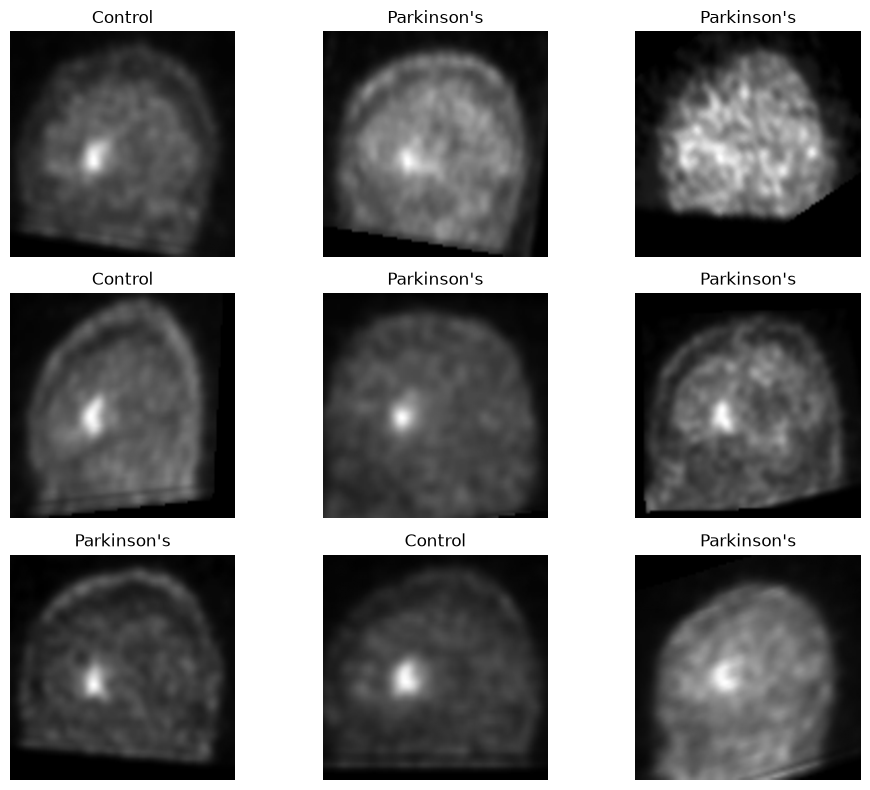

In [32]:
# Take one batch from the training dataset
for images, labels in (
    train_dataset.take(1)
):

    # Create a figure for displaying a sample of MRI images
    plt.figure(
        figsize=(10, 8)
    )

    # Display up to 9 images from the batch
    for i in range(
        min(
            9,
            len(images)
        )
    ):

        # Create a 3 x 3 grid of subplots
        plt.subplot(
            3,
            3,
            i + 1
        )

        # Display the MRI image
        # squeeze() removes the single grayscale channel
        plt.imshow(
            images[i]
            .numpy()
            .squeeze(),
            cmap="gray"
        )

        # Convert the numeric label into a readable class name
        if labels[i] == 1:
            title = "Parkinson's"

        else:
            title = "Control"

        # Add the class name above the image
        plt.title(
            title
        )

        # Hide axis labels and tick marks
        plt.axis(
            "off"
        )

    # Adjust spacing between the images
    plt.tight_layout()

    # Display the sample batch
    plt.show()

In [33]:
# Create a baseline Convolutional Neural Network (CNN)
model = Sequential([

    # Define the expected input shape:
    # 224 x 224 pixels with 1 grayscale channel
    Input(
        shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            1
        )
    ),

    # First convolutional layer
    # Learns 32 low-level image features using 3 x 3 filters
    Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    # Reduce the spatial dimensions of the feature maps
    MaxPooling2D(
        (2, 2)
    ),

    # Second convolutional layer
    # Learns 64 more complex image features
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Reduce the feature-map dimensions again
    MaxPooling2D(
        (2, 2)
    ),

    # Third convolutional layer
    # Learns 128 higher-level features
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    # Further reduce the feature-map dimensions
    MaxPooling2D(
        (2, 2)
    ),

    # Convert the 2D feature maps into a 1D vector
    # so they can be passed into the dense layers
    Flatten(),

    # Fully connected layer containing 128 neurons
    Dense(
        128,
        activation="relu"
    ),

    # Randomly deactivate 50% of neurons during training
    # to help reduce overfitting
    Dropout(
        0.5
    ),

    # Final output layer for binary classification
    # Sigmoid produces a probability between 0 and 1
    Dense(
        1,
        activation="sigmoid"
    )
])

In [34]:
# Display a summary of the CNN architecture,
# including layer types, output shapes, and parameter counts
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Configure the CNN for training
model.compile(

    # Use the Adam optimiser to update the model weights
    optimizer="adam",

    # Use binary cross-entropy because this is
    # a two-class classification problem
    loss=(
        "binary_crossentropy"
    ),

    # Track several performance measures during training
    metrics=[

        # Percentage of predictions classified correctly
        "accuracy",

        # Measures how many predicted Parkinson's cases
        # are actually Parkinson's cases
        tf.keras.metrics.Precision(
            name="precision"
        ),

        # Measures how many actual Parkinson's cases
        # are correctly identified by the model
        tf.keras.metrics.Recall(
            name="recall"
        ),

        # Measures the model's ability to distinguish
        # between Parkinson's and control cases
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [36]:
# Create an EarlyStopping callback to help prevent overfitting
early_stopping = (
    tf.keras.callbacks
    .EarlyStopping(

        # Monitor the validation loss after each epoch
        monitor=(
            "val_loss"
        ),

        # Stop training if validation loss does not improve
        # for 5 consecutive epochs
        patience=5,

        # Restore the model weights from the epoch
        # that achieved the lowest validation loss
        restore_best_weights=True
    )
)

In [38]:
# Set the maximum number of training epochs
EPOCHS = 30

In [41]:
# Train the CNN using the training dataset
history = model.fit(

    # Dataset used to update the model weights
    train_dataset,

    # Dataset used to monitor performance after each epoch
    validation_data=(
        val_dataset
    ),

    # Maximum number of training epochs
    epochs=EPOCHS,

    # Apply the EarlyStopping callback during training
    callbacks=[
        early_stopping
    ]
)

Epoch 1/30


/Users/paulcollingwood/Documents/Source/parkinsons_ml/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


111/111 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - accuracy: 0.8814 - auc: 0.9442 - loss: 0.2975 - precision: 0.9023 - recall: 0.8554 - val_accuracy: 0.8132 - val_auc: 0.9110 - val_loss: 0.3973 - val_precision: 0.8839 - val_recall: 0.7211
Epoch 2/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - accuracy: 0.8847 - auc: 0.9527 - loss: 0.2759 - precision: 0.9001 - recall: 0.8655 - val_accuracy: 0.8184 - val_auc: 0.9057 - val_loss: 0.4105 - val_precision: 0.9116 - val_recall: 0.7053
Epoch 3/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step - accuracy: 0.8966 - auc: 0.9612 - loss: 0.2465 - precision: 0.9169 - recall: 0.8723 - val_accuracy: 0.8184 - val_auc: 0.9184 - val_loss: 0.3903 - val_precision: 0.8954 - val_recall: 0.7211
Epoch 4/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - accuracy: 0.9107 - auc: 0.9674 - loss: 0.2290 - precision: 0.9271 - recall: 0.8915 - val_accuracy: 0.8184 - val_auc: 0.9088 - val_loss: 0.4426 - val_precision: 0.8758 - val_recall: 0.7421
Epoch 5/30
111/111 ━━━━━━━━━━━━

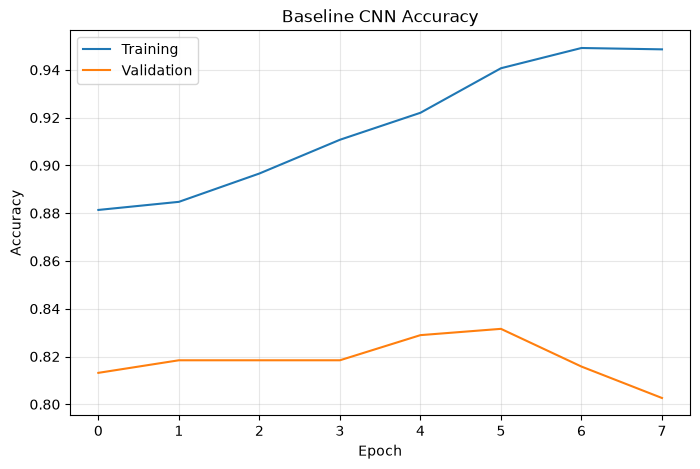

In [42]:
# Create a figure for plotting training and validation accuracy
plt.figure(
    figsize=(8, 5)
)

# Plot the training accuracy recorded after each epoch
plt.plot(
    history.history[
        "accuracy"
    ],
    label="Training"
)

# Plot the validation accuracy recorded after each epoch
plt.plot(
    history.history[
        "val_accuracy"
    ],
    label="Validation"
)

# Label the horizontal axis
plt.xlabel(
    "Epoch"
)

# Label the vertical axis
plt.ylabel(
    "Accuracy"
)

# Add a title to the graph
plt.title(
    "Baseline CNN Accuracy"
)

# Display a legend identifying the two lines
plt.legend()

# Add a light grid to make the graph easier to read
plt.grid(
    alpha=0.3
)

# Display the graph
plt.show()

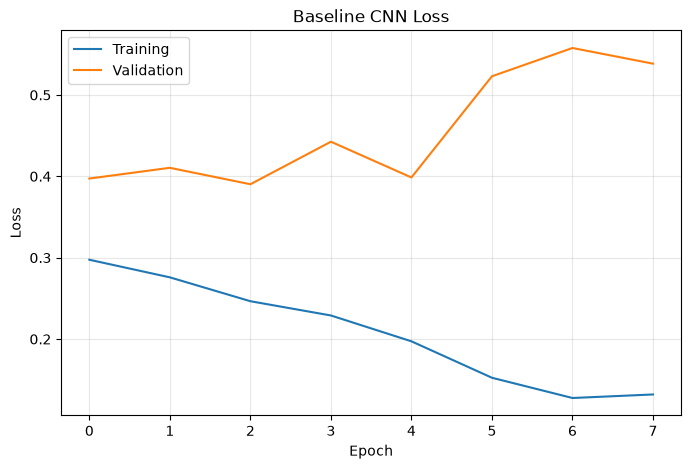

In [43]:
# Create a figure for plotting training and validation loss
plt.figure(
    figsize=(8, 5)
)

# Plot the training loss recorded after each epoch
plt.plot(
    history.history[
        "loss"
    ],
    label="Training"
)

# Plot the validation loss recorded after each epoch
plt.plot(
    history.history[
        "val_loss"
    ],
    label="Validation"
)

# Label the horizontal axis
plt.xlabel(
    "Epoch"
)

# Label the vertical axis
plt.ylabel(
    "Loss"
)

# Add a title to the graph
plt.title(
    "Baseline CNN Loss"
)

# Display a legend identifying the two lines
plt.legend()

# Add a light grid to make the graph easier to read
plt.grid(
    alpha=0.3
)

# Display the graph
plt.show()

In [44]:
# Evaluate the trained CNN using the test dataset
test_results = (
    model.evaluate(
        test_dataset,
        verbose=1
    )
)

# Display the returned test metrics
print(
    test_results
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8052 - auc: 0.8773 - loss: 0.4971 - precision: 0.8042 - recall: 0.8000
[0.497073233127594, 0.8051947951316833, 0.8042327761650085, 0.800000011920929, 0.8773278594017029]


In [45]:
# Loop through each metric name and its corresponding test result
for metric_name, value in zip(
    model.metrics_names,
    test_results
):

    # Display the metric name and value rounded to 4 decimal places
    print(
        f"{metric_name}: "
        f"{value:.4f}"
    )

loss: 0.4971
compile_metrics: 0.8052


In [46]:
# Use the trained CNN to predict Parkinson's probabilities
# for every image in the test dataset
probabilities = (
    model.predict(
        test_dataset
    )

    # Convert the output from shape (n, 1)
    # into a one-dimensional array of probabilities
    .flatten()
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [47]:
# Convert the predicted probabilities into binary class predictions
predictions = (
    probabilities
    >= 0.5
).astype(int)

In [48]:
# Extract the true class labels from the test DataFrame
true_labels = (
    test_df[
        "label"
    ]

    # Convert the labels to integers
    .astype(int)

    # Convert the pandas Series into a NumPy array
    .values
)

In [51]:
# Create a confusion matrix by comparing the true test labels
# with the model's predicted class labels
cm = confusion_matrix(
    true_labels,
    predictions
)

# Display the confusion matrix
print(cm)

[[158  37]
 [ 38 152]]


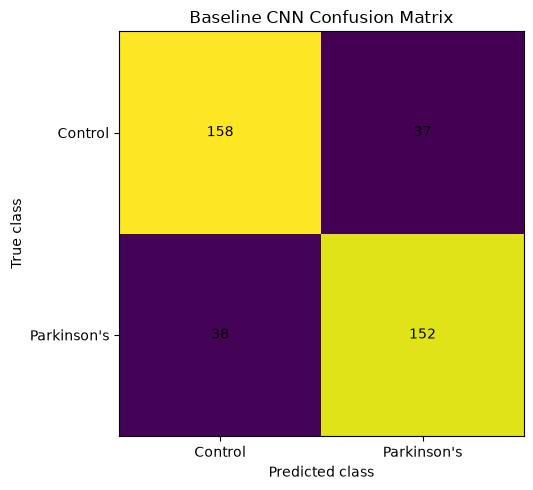

In [52]:
# Create a figure and axis for displaying the confusion matrix
fig, ax = plt.subplots(
    figsize=(6, 5)
)

# Create the confusion matrix from the true labels
# and the model's predicted labels
display = (
    tf.math.confusion_matrix(
        true_labels,
        predictions
    )
)

# Display the confusion matrix as an image
ax.imshow(
    display
)

# Label the horizontal axis
ax.set_xlabel(
    "Predicted class"
)

# Label the vertical axis
ax.set_ylabel(
    "True class"
)

# Set the positions of the x-axis labels
ax.set_xticks(
    [0, 1]
)

# Add readable class names to the x-axis
ax.set_xticklabels(
    [
        "Control",
        "Parkinson's"
    ]
)

# Set the positions of the y-axis labels
ax.set_yticks(
    [0, 1]
)

# Add readable class names to the y-axis
ax.set_yticklabels(
    [
        "Control",
        "Parkinson's"
    ]
)

# Add the numerical count inside each
# cell of the confusion matrix
for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            int(
                display[
                    i,
                    j
                ]
            ),
            ha="center",
            va="center"
        )

# Add a title to the confusion matrix
plt.title(
    "Baseline CNN Confusion Matrix"
)

# Adjust the layout to avoid overlapping labels
plt.tight_layout()

# Display the confusion matrix
plt.show()

In [53]:
# Generate and display a classification report
# comparing the true test labels with the model predictions
print(
    classification_report(
        true_labels,
        predictions,

        # Display readable class names instead of 0 and 1
        target_names=[
            "Control",
            "Parkinson's"
        ]
    )
)

              precision    recall  f1-score   support

     Control       0.81      0.81      0.81       195
 Parkinson's       0.80      0.80      0.80       190

    accuracy                           0.81       385
   macro avg       0.81      0.81      0.81       385
weighted avg       0.81      0.81      0.81       385



In [54]:
# Extract the four values from the confusion matrix:
# true negatives, false positives, false negatives, and true positives
tn, fp, fn, tp = (
    confusion_matrix(
        true_labels,
        predictions
    )
    .ravel()
)

# Calculate specificity:
# the proportion of control cases correctly identified as control
specificity = (
    tn / (
        tn + fp
    )
)

# Calculate sensitivity:
# the proportion of Parkinson's cases correctly identified
sensitivity = (
    tp / (
        tp + fn
    )
)

# Display sensitivity rounded to 4 decimal places
print(
    f"Sensitivity: "
    f"{sensitivity:.4f}"
)

# Display specificity rounded to 4 decimal places
print(
    f"Specificity: "
    f"{specificity:.4f}"
)

Sensitivity: 0.8000
Specificity: 0.8103


In [55]:
# Create the path to the folder where trained models will be saved
MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

# Create the models directory if it does not already exist
MODEL_DIR.mkdir(
    parents=True,   # Create any missing parent folders
    exist_ok=True   # Do not raise an error if the folder already exists
)

In [56]:
# Create the full path for saving the trained baseline CNN
model_file = (
    MODEL_DIR
    / "baseline_mri_cnn.keras"
)

# Save the complete Keras model to disk
# This includes the model architecture, trained weights,
# and compile configuration
model.save(
    model_file
)

# Display the location of the saved model
print(
    model_file
)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/models/baseline_mri_cnn.keras


In [57]:
# Convert the training history recorded by Keras
# into a pandas DataFrame
history_df = (
    pd.DataFrame(
        history.history
    )
)

# Create the full path for the training history CSV file
history_file = (
    PROCESSED_DIR
    / "baseline_training_history.csv"
)

# Save the training history to a CSV file
history_df.to_csv(
    history_file,
    index=False   # Do not save the DataFrame row numbers
)

# Display the location of the saved history file
print(
    history_file
)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/baseline_training_history.csv


In [58]:
# Create a dictionary containing the main test metrics
results = {

    # Calculate the overall test accuracy
    "test_accuracy":
        accuracy_score(
            true_labels,
            predictions
        ),

    # Store the sensitivity
    # This is the proportion of Parkinson's cases correctly identified
    "sensitivity":
        sensitivity,

    # Store the specificity
    # This is the proportion of control cases correctly identified
    "specificity":
        specificity
}

# Display the results dictionary
results

{'test_accuracy': 0.8051948051948052,
 'sensitivity': np.float64(0.8),
 'specificity': np.float64(0.8102564102564103)}

In [59]:
# Create a copy of the test DataFrame
# so the original test data is not changed
test_results_df = (
    test_df.copy()
)

# Add the predicted Parkinson's probability
# for each processed MRI slice
test_results_df[
    "probability"
] = probabilities

# Add the final binary prediction for each slice
# 0 = control
# 1 = Parkinson's
test_results_df[
    "prediction"
] = predictions

In [60]:
# Display the first 10 test results using only the
# most useful columns for checking model predictions
test_results_df[
    [
        "subject_id",
        "class",
        "slice_index",
        "probability",
        "prediction"
    ]
].head(10)

,subject_id,class,slice_index,probability,prediction
0,PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011...,control,35,0.508595,1
1,PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011...,control,40,0.594402,1
2,PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011...,control,45,0.613858,1
3,PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011...,control,50,0.640450,1
4,PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011...,control,55,0.878874,1
5,PPMI_118726_NM_Reconstructed_DaTSCAN_Br_202201...,control,35,0.094817,0
6,PPMI_118726_NM_Reconstructed_DaTSCAN_Br_202201...,control,40,0.274011,0
7,PPMI_118726_NM_Reconstructed_DaTSCAN_Br_202201...,control,45,0.280476,0
8,PPMI_118726_NM_Reconstructed_DaTSCAN_Br_202201...,control,50,0.221380,0
9,PPMI_118726_NM_Reconstructed_DaTSCAN_Br_202201...,control,55,0.170244,0


In [61]:
# Group the slice-level test predictions by subject
# so each subject receives one combined prediction
subject_predictions = (
    test_results_df
    .groupby(
        [
            "subject_id",
            "class",
            "label"
        ]
    )

    # Calculate the average predicted probability
    # across all MRI slices belonging to each subject
    .agg(
        mean_probability=(
            "probability",
            "mean"
        )
    )

    # Convert the grouped index back into normal DataFrame columns
    .reset_index()
)

In [62]:
# Convert each subject's average predicted probability
# into a final binary class prediction
subject_predictions[
    "prediction"
] = (
    subject_predictions[
        "mean_probability"
    ]
    >= 0.5
).astype(int)

In [63]:
# Display the first five subject-level predictions
subject_predictions.head()

,subject_id,class,label,mean_probability,prediction
0,PPMI_102447_NM_Reconstructed_DaTSCAN_Br_202110...,control,0,0.086186,0
1,PPMI_116231_NM_Reconstructed_DaTSCAN_Br_202112...,control,0,0.147199,0
2,PPMI_118726_NM_Reconstructed_DaTSCAN_Br_202201...,control,0,0.208186,0
3,PPMI_128335_NM_Reconstructed_DaTSCAN_Br_202201...,control,0,0.099886,0
4,PPMI_138022_NM_Reconstructed_DaTSCAN_Br_202204...,control,0,0.038797,0


In [64]:
# Calculate the overall subject-level accuracy
subject_accuracy = (
    accuracy_score(
        subject_predictions[
            "label"
        ],
        subject_predictions[
            "prediction"
        ]
    )
)

# Display the subject-level accuracy
print(
    "Subject-level accuracy:",
    subject_accuracy
)

Subject-level accuracy: 0.8181818181818182


In [65]:
# Generate and display a classification report
# using the subject-level true labels and predictions
print(
    classification_report(
        subject_predictions[
            "label"
        ],
        subject_predictions[
            "prediction"
        ],

        # Display readable class names instead of 0 and 1
        target_names=[
            "Control",
            "Parkinson's"
        ]
    )
)

              precision    recall  f1-score   support

     Control       0.82      0.82      0.82        39
 Parkinson's       0.82      0.82      0.82        38

    accuracy                           0.82        77
   macro avg       0.82      0.82      0.82        77
weighted avg       0.82      0.82      0.82        77



In [66]:
# Create a subject-level confusion matrix by comparing
# each subject's true label with the final subject prediction
subject_cm = (
    confusion_matrix(
        subject_predictions[
            "label"
        ],
        subject_predictions[
            "prediction"
        ]
    )
)

# Display the subject-level confusion matrix
print(
    subject_cm
)

[[32  7]
 [ 7 31]]
